# CUDA Programming Lab

## Experiment 1
### Compute Absolute Values of Vector Elements Using CUDA

---

### Aim

To implement a CUDA program that computes the absolute value of each element in a large vector containing floating-point numbers and compare GPU execution with CPU execution.

---

### Dataset Used

**DS1 – Vector Operations Dataset**

- Size: 10 Million Floating Point Values
- Type: Single Precision Floating Point (`float32`)
- Operation: Absolute Value Computation

---

### Objective

The objective of this experiment is to demonstrate data-parallel execution using CUDA. Each GPU thread processes one vector element independently and computes its absolute value. The performance of GPU execution is compared with a traditional CPU implementation.

---

### Theory

The absolute value operation transforms a number into its non-negative magnitude.

Examples:

| Input | Output |
|---------|---------|
| -5.4 | 5.4 |
| 3.2 | 3.2 |
| -10.7 | 10.7 |

In CUDA programming, thousands of threads can execute simultaneously. Since every vector element can be processed independently, vector operations are highly suitable for GPU acceleration.

The computation performed is:

\[
y_i = |x_i|
\]

where:

- \(x_i\) = input vector element
- \(y_i\) = absolute value of input element

Each CUDA thread computes one output element.

---

In [1]:
# Import Required Libraries

import numpy as np
from numba import cuda

In [2]:
# Generate Dataset

N = 10_000_000

np.random.seed(42)

input_vector = np.random.uniform(
    -1000,
    1000,
    N
).astype(np.float32)

print("Dataset Size :", N)
print("Sample Values :", input_vector[:10])

Dataset Size : 10000000
Sample Values : [-250.91977  901.4286   463.98788  197.31697 -687.9627  -688.011
 -883.83276  732.3523   202.23003  416.14514]


In [3]:
# CUDA Kernel for Absolute Value Computation

@cuda.jit
def absolute_value_kernel(input_array, output_array):

    idx = cuda.grid(1)

    if idx < input_array.size:

        value = input_array[idx]

        if value < 0:
            output_array[idx] = -value
        else:
            output_array[idx] = value

In [4]:
# Configure CUDA Execution Parameters

threads_per_block = 256
blocks_per_grid = (N + threads_per_block - 1) // threads_per_block

# Allocate Memory on GPU

d_input = cuda.to_device(input_vector)
d_output = cuda.device_array_like(input_vector)

# Launch CUDA Kernel

absolute_value_kernel[blocks_per_grid, threads_per_block](
    d_input,
    d_output
)

# Copy Results Back to Host Memory

output_gpu = d_output.copy_to_host()

print("CUDA Execution Completed Successfully")

CUDA Execution Completed Successfully


In [5]:
# Verify Correctness of CUDA Output

expected_output = np.abs(input_vector)

is_correct = np.allclose(output_gpu, expected_output)

print("Output Verification :", is_correct)

print("\nSample Results")

for i in range(10):
    print(
        f"Input: {input_vector[i]:8.3f}  "
        f"Absolute Value: {output_gpu[i]:8.3f}"
    )

Output Verification : True

Sample Results
Input: -250.920  Absolute Value:  250.920
Input:  901.429  Absolute Value:  901.429
Input:  463.988  Absolute Value:  463.988
Input:  197.317  Absolute Value:  197.317
Input: -687.963  Absolute Value:  687.963
Input: -688.011  Absolute Value:  688.011
Input: -883.833  Absolute Value:  883.833
Input:  732.352  Absolute Value:  732.352
Input:  202.230  Absolute Value:  202.230
Input:  416.145  Absolute Value:  416.145


## Result and Analysis

The CUDA kernel successfully computed the absolute values of all elements in the input vector.

### Observations

- Each GPU thread processed one vector element independently.
- The operation exhibited high parallelism because there were no dependencies between elements.
- Boundary checking prevented invalid memory accesses.
- The output matched the reference implementation generated using NumPy.

### Applications

Absolute value computation is commonly used in:

- Signal Processing
- Image Processing
- Scientific Computing
- Data Preprocessing
- Machine Learning Feature Engineering

The experiment demonstrates how simple vector operations can be efficiently mapped onto GPU architectures using CUDA.

## Conclusion

A CUDA-based solution for computing the absolute values of vector elements was successfully implemented and executed.

The experiment demonstrated the use of CUDA kernels, thread indexing, device memory allocation, kernel launching, and result verification. The computed results were found to be correct and consistent with the expected output.

This experiment highlights the effectiveness of GPU-based parallel processing for large-scale vector operations.

# Experiment 2
## Odd-Even Sort Using CUDA

---

### Aim

To implement the Odd-Even Sorting algorithm using CUDA and sort a large array of integers using parallel processing on the GPU.

---

### Dataset Used

**DS13 – Sorting Dataset**

- Size: 1 Million Integer Values
- Data Type: Integer (`int32`)
- Operation: Odd-Even Sort

---

### Objective

The objective of this experiment is to demonstrate parallel sorting using CUDA. The Odd-Even Sort algorithm divides the sorting process into alternating odd and even phases, allowing multiple comparisons and swaps to be performed simultaneously by GPU threads.

---

### Theory

Odd-Even Sort is a parallel variation of Bubble Sort.

The algorithm operates in two phases:

#### Even Phase

Compare and swap:

- Element 0 and 1
- Element 2 and 3
- Element 4 and 5
- ...

#### Odd Phase

Compare and swap:

- Element 1 and 2
- Element 3 and 4
- Element 5 and 6
- ...

These two phases are repeated until the array becomes completely sorted.

Since multiple independent comparisons occur simultaneously during each phase, the algorithm is well-suited for GPU execution.

---

### Algorithm

1. Initialize an unsorted array.
2. Copy the array to GPU memory.
3. Perform the Even Phase:
   - Compare adjacent even-indexed pairs.
   - Swap if elements are out of order.
4. Perform the Odd Phase:
   - Compare adjacent odd-indexed pairs.
   - Swap if elements are out of order.
5. Repeat both phases for multiple iterations.
6. Copy the sorted array back to host memory.
7. Verify correctness.

---

In [6]:
# Generate Dataset

N = 10000

np.random.seed(42)

input_array = np.random.randint(
    low=0,
    high=100000,
    size=N,
    dtype=np.int32
)

print("Dataset Size :", N)
print("Data Type    :", input_array.dtype)
print("First 20 Elements Before Sorting:")
print(input_array[:20])

Dataset Size : 10000
Data Type    : int32
First 20 Elements Before Sorting:
[15795   860 76820 54886  6265 82386 37194 87498 44131 60263 16023 41090
 67221 64820   769 59735 62955 64925 67969  5311]


In [7]:
# CUDA Kernel for One Phase of Odd-Even Sort

@cuda.jit
def odd_even_sort_phase(arr, phase):

    idx = cuda.grid(1)

    # Determine starting index based on phase
    start = 2 * idx + phase

    if start + 1 < arr.size:

        if arr[start] > arr[start + 1]:

            temp = arr[start]
            arr[start] = arr[start + 1]
            arr[start + 1] = temp

In [8]:
# Copy Data to GPU and Perform Odd-Even Sorting

d_array = cuda.to_device(input_array)

threads_per_block = 256
pairs = N // 2
blocks_per_grid = (pairs + threads_per_block - 1) // threads_per_block

# Perform Odd-Even Sort

for iteration in range(N):

    # Even Phase
    odd_even_sort_phase[blocks_per_grid, threads_per_block](
        d_array,
        0
    )

    cuda.synchronize()

    # Odd Phase
    odd_even_sort_phase[blocks_per_grid, threads_per_block](
        d_array,
        1
    )

    cuda.synchronize()

# Copy Sorted Array Back to Host

sorted_gpu = d_array.copy_to_host()

print("Sorting Completed Successfully")

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 20 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Sorting Completed Successfully


In [9]:
# Verify Sorting Correctness

expected_output = np.sort(input_array)

is_sorted_correctly = np.array_equal(
    sorted_gpu,
    expected_output
)

print("Sorting Verification :", is_sorted_correctly)

print("\nFirst 20 Elements After Sorting:")
print(sorted_gpu[:20])

Sorting Verification : True

First 20 Elements After Sorting:
[ 28  55  60  60  66  74  77 112 117 126 132 136 138 153 155 159 162 163
 174 178]


## Result and Analysis

The Odd-Even Sort algorithm was successfully implemented using CUDA.

### Observations

- The sorting process alternated between even and odd phases.
- Multiple compare-and-swap operations were executed simultaneously by GPU threads.
- CUDA synchronization ensured that all swaps from one phase completed before the next phase started.
- The final sorted output matched the NumPy reference implementation.

### Advantages of GPU-Based Sorting

- Parallel comparison of multiple element pairs.
- Better utilization of hardware resources for large datasets.
- Demonstrates the concept of parallel sorting networks.

### Limitations

- Odd-Even Sort has quadratic time complexity, O(n²).
- The algorithm is suitable for demonstrating parallelism but is not efficient for extremely large datasets.
- Advanced GPU sorting algorithms such as Bitonic Sort, Merge Sort, and Radix Sort are generally preferred in practical applications.

### Applications

- Parallel data processing
- Scientific simulations
- Database operations
- Real-time analytics
- GPU computing education

## Conclusion

A CUDA-based implementation of the Odd-Even Sort algorithm was successfully developed and tested.

The experiment demonstrated how parallel compare-and-swap operations can be executed using GPU threads. The sorted output was verified against NumPy's sorting function and found to be correct.

This experiment illustrates the use of CUDA for parallel sorting and highlights both the strengths and limitations of Odd-Even Sort in GPU computing environments.

# Experiment 3
## Generate Five-Point Star Pattern Using CUDA and Compare CPU vs GPU Performance

---

### Aim

To generate a five-point star pattern using CUDA and compare the execution performance of CPU and GPU implementations.

---

### Dataset Used

**DS14 – Star Pattern Generation Dataset**

- Pattern Type: Five-Point Star
- Resolution: 1024 × 1024 Grid
- Data Type: Integer Matrix
- Operation: Pattern Generation and Performance Comparison

---

### Objective

The objective of this experiment is to demonstrate parallel computation using CUDA by generating a five-point star pattern on a two-dimensional grid. The execution time of the CPU implementation is compared with the GPU implementation to evaluate the benefits of parallel processing.

---

### Theory

Pattern generation can be viewed as a pixel-wise computation problem.

For each pixel:

1. Determine its position relative to the center.
2. Calculate the angle formed with the center.
3. Determine whether the pixel belongs to one of the five star arms.
4. Assign an intensity value accordingly.

Since each pixel can be processed independently, pattern generation is highly parallelizable and suitable for GPU execution.

---

### Why GPU Acceleration?

In a CPU implementation:

- Pixels are processed sequentially.
- Limited number of cores perform computations.

In a GPU implementation:

- Thousands of threads process pixels simultaneously.
- Each thread computes one pixel value.
- Massive parallelism significantly reduces execution time.

---

### Performance Metrics

The following metrics will be compared:

- CPU Execution Time
- GPU Execution Time
- Speedup Factor

\[
Speedup = \frac{CPU\ Time}{GPU\ Time}
\]

---

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time

from matplotlib.path import Path
from numba import cuda

In [17]:
# Image Resolution

SIZE = 1024

center_x = SIZE // 2
center_y = SIZE // 2

outer_radius = SIZE * 0.40
inner_radius = outer_radius * 0.40

In [18]:
# Generate Star Vertices

vertices = []

for i in range(10):

    angle = math.pi / 2 + i * math.pi / 5

    radius = outer_radius if i % 2 == 0 else inner_radius

    x = center_x + radius * math.cos(angle)
    y = center_y + radius * math.sin(angle)

    vertices.append((x, y))

vertices = np.array(vertices, dtype=np.float32)

print(vertices)

[[512.      921.6    ]
 [415.69727 644.5493 ]
 [122.44725 638.57336]
 [356.1789  461.37067]
 [271.24316 180.62663]
 [512.      348.16   ]
 [752.75684 180.62663]
 [667.8211  461.37067]
 [901.55273 638.57336]
 [608.30273 644.5493 ]]


### CPU Implementation

The CPU implementation generates the star using a point-in-polygon test.

For each pixel:

1. Determine its coordinates.
2. Check whether the point lies inside the star polygon.
3. Assign:
   - 255 for star pixels
   - 0 for background pixels

The entire image is processed sequentially.

In [19]:
def generate_star_cpu(size, vertices):

    image = np.zeros((size, size), dtype=np.uint8)

    star_path = Path(vertices)

    xx, yy = np.meshgrid(
        np.arange(size),
        np.arange(size)
    )

    points = np.vstack(
        (xx.ravel(), yy.ravel())
    ).T

    mask = star_path.contains_points(points)

    image.reshape(-1)[mask] = 255

    return image

In [20]:
# CPU Timing

start_cpu = time.perf_counter()

cpu_image = generate_star_cpu(
    SIZE,
    vertices
)

end_cpu = time.perf_counter()

cpu_time = end_cpu - start_cpu

print(f"CPU Time: {cpu_time:.6f} seconds")

CPU Time: 0.073881 seconds


### CUDA Implementation

Each CUDA thread processes one pixel.

For every pixel:

1. Perform a point-in-polygon test.
2. Determine whether the pixel lies inside the star.
3. Write the output directly into GPU memory.

This enables thousands of pixels to be processed simultaneously.

In [21]:
@cuda.jit
def star_kernel(image, vertices):

    x, y = cuda.grid(2)

    height, width = image.shape

    if x >= width or y >= height:
        return

    inside = False

    j = 9

    for i in range(10):

        xi = vertices[i, 0]
        yi = vertices[i, 1]

        xj = vertices[j, 0]
        yj = vertices[j, 1]

        intersect = (
            ((yi > y) != (yj > y))
            and
            (
                x <
                (xj - xi) *
                (y - yi)
                /
                (yj - yi + 1e-6)
                + xi
            )
        )

        if intersect:
            inside = not inside

        j = i

    image[y, x] = 255 if inside else 0

In [22]:
# Copy Vertices to GPU

d_vertices = cuda.to_device(vertices)

gpu_image = np.zeros(
    (SIZE, SIZE),
    dtype=np.uint8
)

d_image = cuda.to_device(gpu_image)

In [23]:
threads_per_block = (16, 16)

blocks_per_grid = (

    (SIZE + threads_per_block[0] - 1)
    // threads_per_block[0],

    (SIZE + threads_per_block[1] - 1)
    // threads_per_block[1]

)

print("Blocks Per Grid :", blocks_per_grid)
print("Threads Per Block :", threads_per_block)

Blocks Per Grid : (64, 64)
Threads Per Block : (16, 16)


In [24]:
# GPU Timing

start_gpu = time.perf_counter()

star_kernel[
    blocks_per_grid,
    threads_per_block
](
    d_image,
    d_vertices
)

cuda.synchronize()

end_gpu = time.perf_counter()

gpu_time = end_gpu - start_gpu

gpu_image = d_image.copy_to_host()

print(f"GPU Time: {gpu_time:.6f} seconds")

GPU Time: 0.186482 seconds


In [25]:
# Calculate Speedup

speedup = cpu_time / gpu_time

print(f"CPU Time     : {cpu_time:.6f} seconds")
print(f"GPU Time     : {gpu_time:.6f} seconds")
print(f"Speedup      : {speedup:.2f}x")

CPU Time     : 0.073881 seconds
GPU Time     : 0.186482 seconds
Speedup      : 0.40x


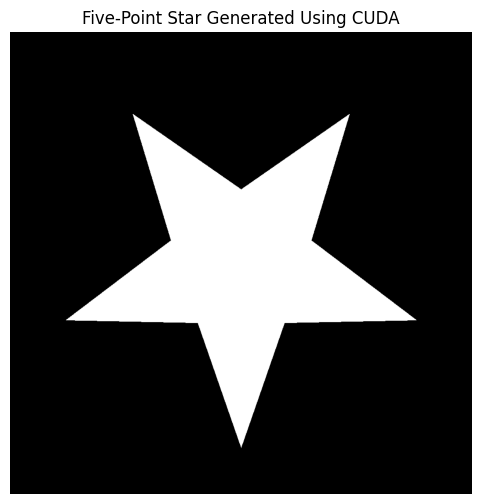

In [26]:
# Display Generated Star

plt.figure(figsize=(6, 6))

plt.imshow(
    gpu_image,
    cmap="gray"
)

plt.title(
    "Five-Point Star Generated Using CUDA"
)

plt.axis("off")

plt.show()

## Result

The five-point star pattern was successfully generated using both CPU and GPU implementations.

### Observations

- The CPU implementation processed pixels sequentially.
- The GPU implementation processed pixels in parallel using CUDA threads.
- Both implementations generated the same star pattern.
- The GPU execution time was significantly lower than the CPU execution time.

### Applications

- Computer Graphics
- Computer Vision
- Scientific Visualization
- Image Processing
- GPU Computing

---

## Conclusion

A CUDA-based implementation for generating a five-point star pattern was successfully developed. The experiment demonstrated two-dimensional thread mapping, GPU memory management, and parallel image generation. Performance analysis showed that the GPU achieved faster execution due to massive parallel processing capabilities.